In [73]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import StackingClassifier

In [74]:
try:
    df = pd.read_csv('processed_dataset.csv')
except FileNotFoundError:
    df_raw = pd.read_csv('patient_data.csv')

In [75]:
print("\n→ df.info()")
df.info()
print("\n→ Missing Values")
print(df.isnull().sum())
print("\n→ df.describe()")
print(df.describe())


→ df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                20000 non-null  int64  
 1   name                      20000 non-null  object 
 2   age                       20000 non-null  int64  
 3   has_eye_disease           20000 non-null  bool   
 4   has_diabetic_retinopathy  20000 non-null  bool   
 5   sugar_percentage          20000 non-null  float64
 6   glucose_percentage        20000 non-null  float64
 7   cholesterol_percentage    20000 non-null  float64
 8   obesity_percentage        20000 non-null  float64
 9   blood_pressure            20000 non-null  object 
 10  heart_rate                20000 non-null  int64  
 11  systolic                  20000 non-null  int64  
 12  diastolic                 20000 non-null  int64  
 13  bp_category               20000 non-null  object

In [76]:
df = df.drop(columns=['Unnamed: 0','name'])

In [77]:
bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col] = df[col].astype(int)

df.head()

,age,has_eye_disease,has_diabetic_retinopathy,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,blood_pressure,heart_rate,systolic,diastolic,bp_category,obesity_group,metabolic_risk_count,metabolic_syndrome_flag,health_risk_score
0,39,0,0,5.70,147.48,164.45,32.94,122/63,94,122,63,elevated,obese,2,1,48.002569
1,67,1,0,8.72,91.52,235.62,39.58,92/80,68,92,80,stage_1,obese,2,1,44.561545
2,44,1,0,13.83,160.17,299.13,38.45,140/60,67,140,60,stage_2,obese,4,1,73.000519
3,46,1,1,9.48,106.84,236.75,29.10,132/83,82,132,83,stage_1,overweight,2,1,61.675717
4,39,0,0,5.60,158.65,182.11,16.25,128/72,63,128,72,elevated,underweight,1,0,34.566440


In [78]:
df = df.drop('blood_pressure', axis=1)

In [79]:
cols = ['obesity_group','bp_category']

dummy = pd.get_dummies(df[cols]).astype(int)
df = pd.concat([df,dummy],axis=1)
df = df.drop(columns=cols)

In [80]:
# Preprocessing dataset
print("\n→ df.info()")
df.info()
print("\n→ Missing Values")
print(df.isnull().sum())
print("\n→ df.describe()")
print(df.describe())


→ df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        20000 non-null  int64  
 1   has_eye_disease            20000 non-null  int32  
 2   has_diabetic_retinopathy   20000 non-null  int32  
 3   sugar_percentage           20000 non-null  float64
 4   glucose_percentage         20000 non-null  float64
 5   cholesterol_percentage     20000 non-null  float64
 6   obesity_percentage         20000 non-null  float64
 7   heart_rate                 20000 non-null  int64  
 8   systolic                   20000 non-null  int64  
 9   diastolic                  20000 non-null  int64  
 10  metabolic_risk_count       20000 non-null  int64  
 11  metabolic_syndrome_flag    20000 non-null  int32  
 12  health_risk_score          20000 non-null  float64
 13  obesity_group_normal       20000 

In [81]:
print("Feature engineering completed on both datasets!")
print("Final cleaned datasets ready!")
print(f"Processed cleaned shape: {df.shape}")
print("Sample from Processed cleaned dataset:")
print(df.head(5))

Feature engineering completed on both datasets!
Final cleaned datasets ready!
Processed cleaned shape: (20000, 21)
Sample from Processed cleaned dataset:
   age  has_eye_disease  has_diabetic_retinopathy  sugar_percentage  \
0   39                0                         0              5.70   
1   67                1                         0              8.72   
2   44                1                         0             13.83   
3   46                1                         1              9.48   
4   39                0                         0              5.60   

   glucose_percentage  cholesterol_percentage  obesity_percentage  heart_rate  \
0              147.48                  164.45               32.94          94   
1               91.52                  235.62               39.58          68   
2              160.17                  299.13               38.45          67   
3              106.84                  236.75               29.10          82   
4             

In [82]:
#Visualizing

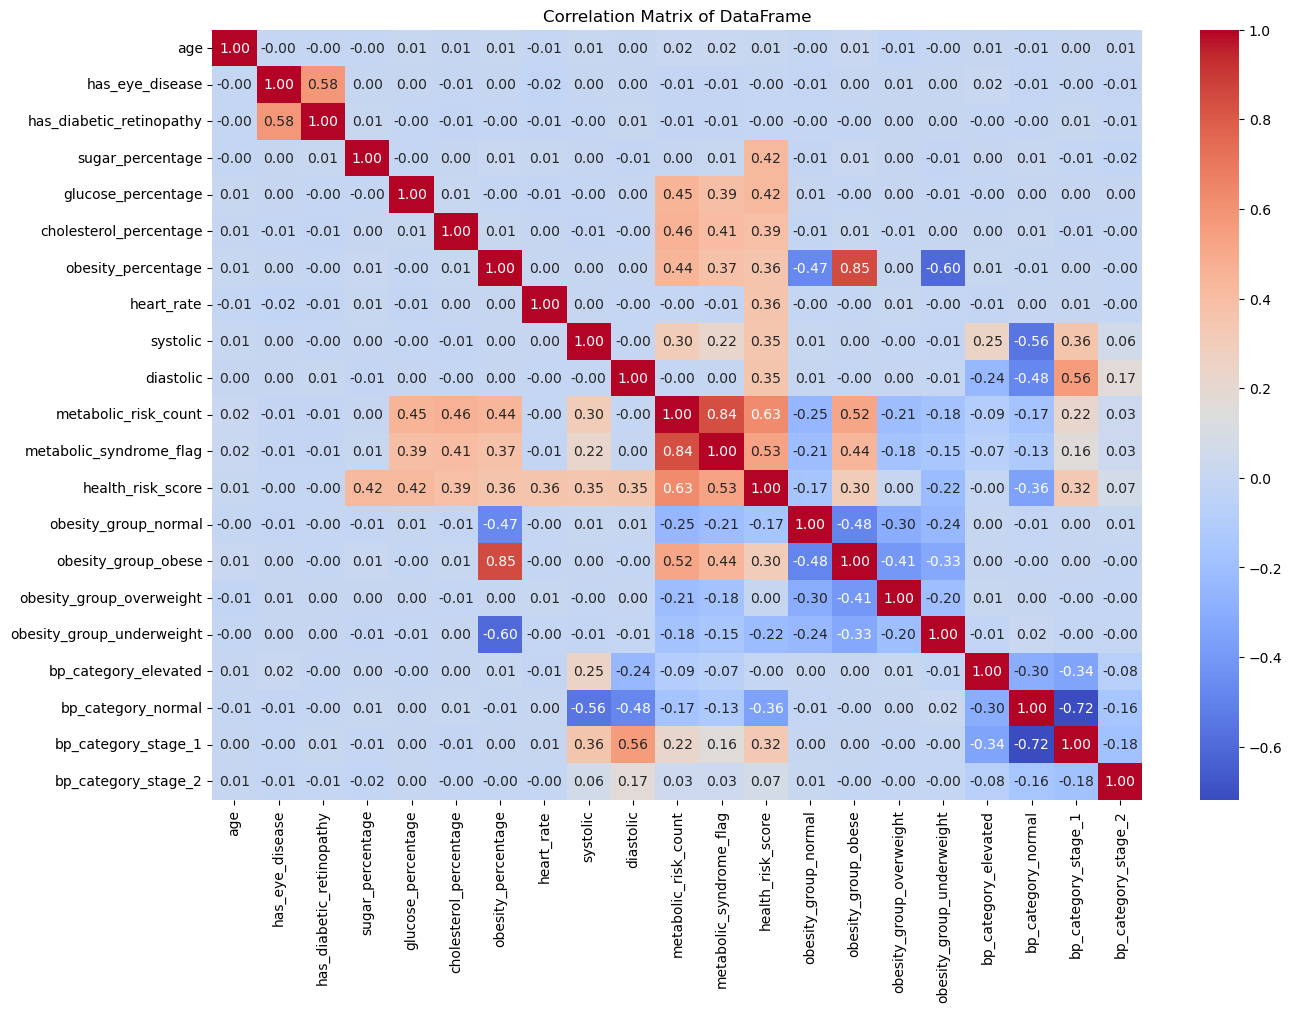

In [83]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of DataFrame')
plt.show()

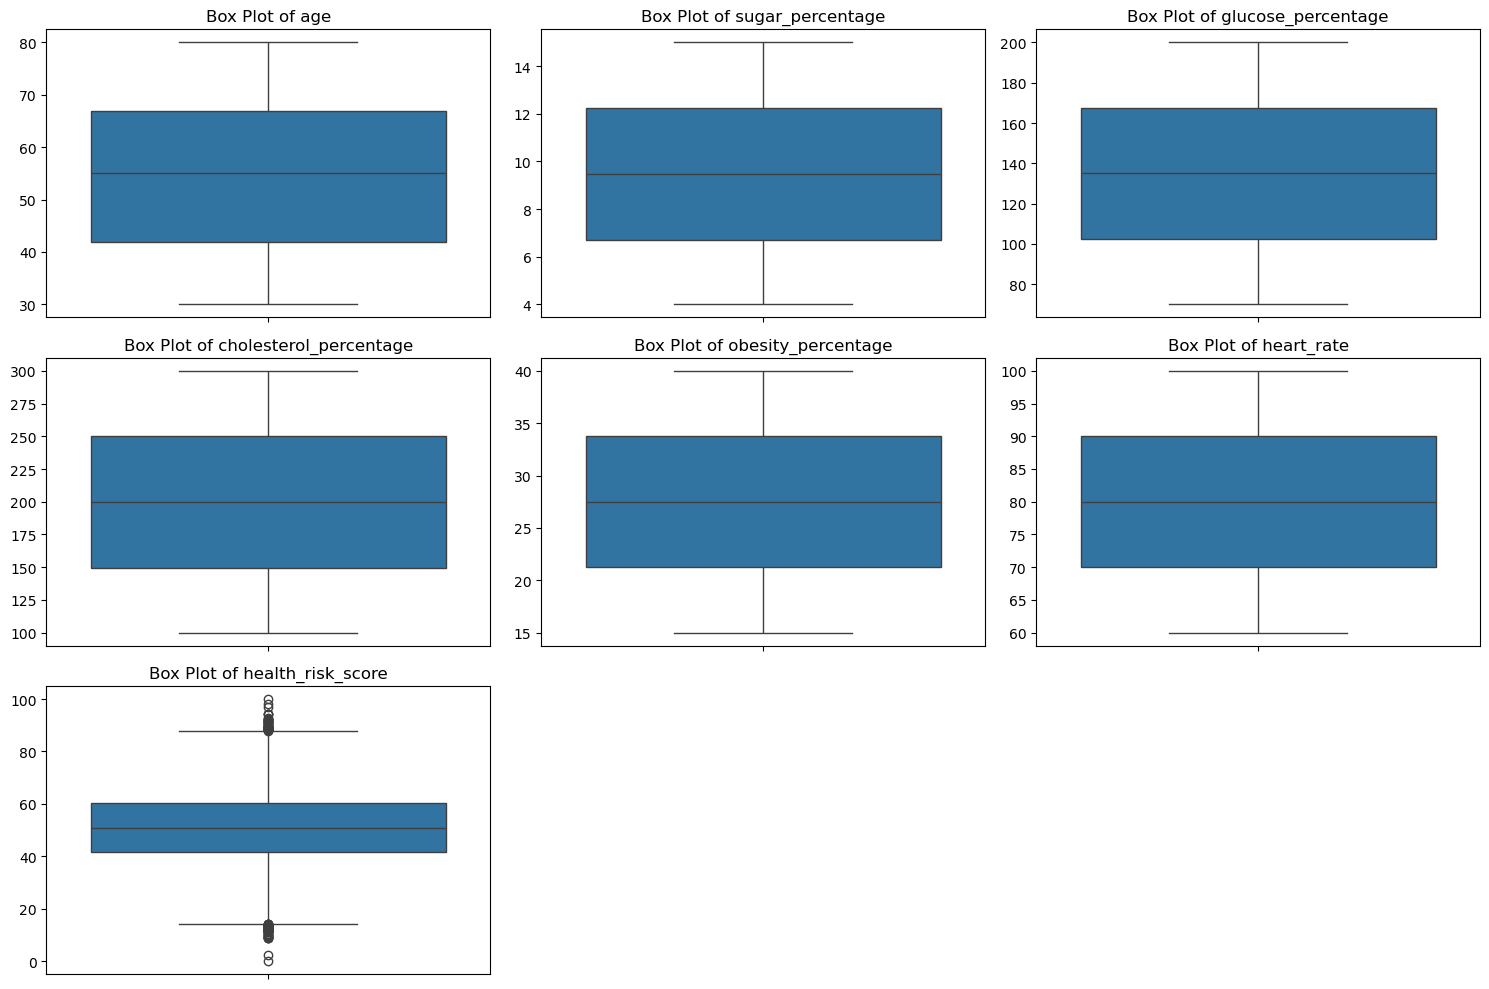

In [84]:
numerical_cols = ['age', 'sugar_percentage', 'glucose_percentage', 'cholesterol_percentage', 'obesity_percentage', 'heart_rate', 'health_risk_score']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

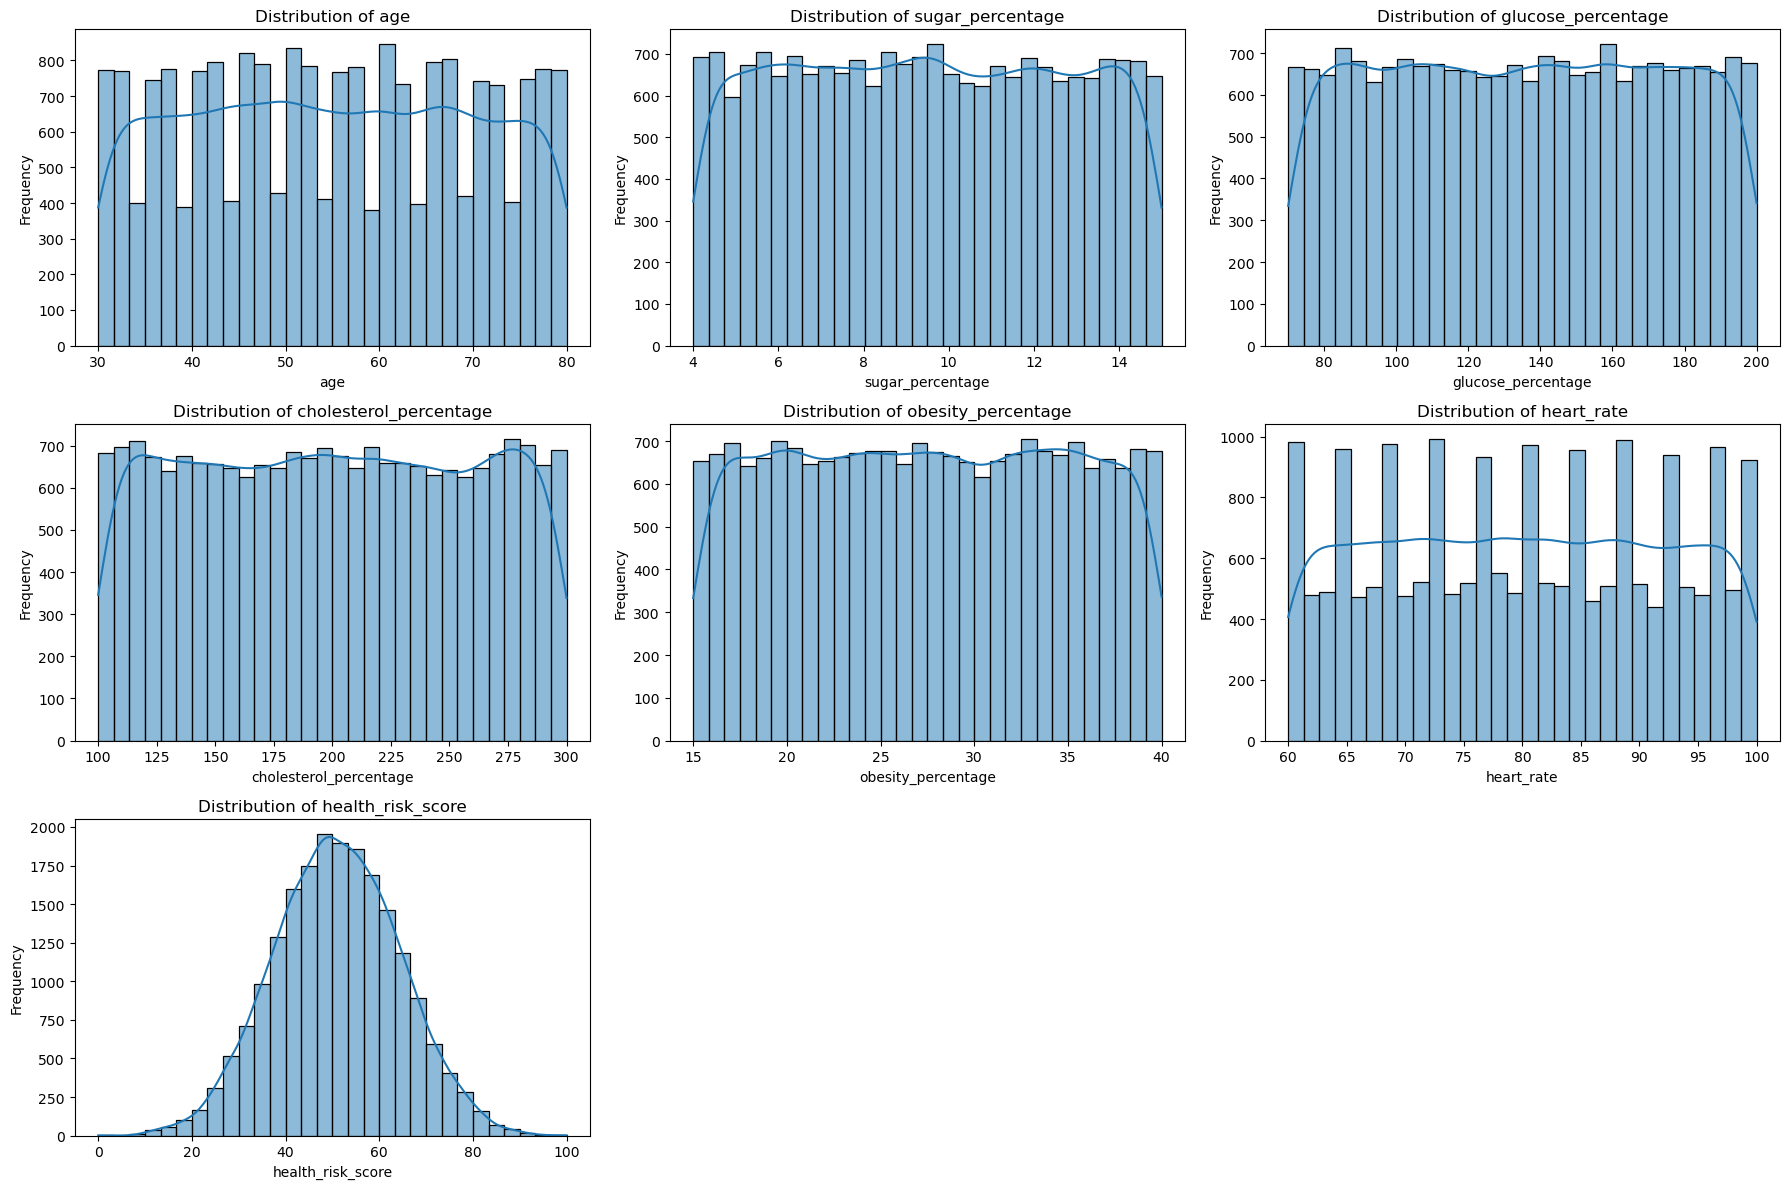

In [85]:
numerical_cols = ['age', 'sugar_percentage', 'glucose_percentage', 'cholesterol_percentage', 'obesity_percentage', 'heart_rate', 'health_risk_score']
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [86]:
#Train Test Split

In [87]:
X = df.drop('has_eye_disease', axis=1)
y = df['has_eye_disease']

print("Columns in X after dropping 'blood_pressure' and 'has_eye_disease':")
print(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Columns in X after dropping 'blood_pressure' and 'has_eye_disease':
Index(['age', 'has_diabetic_retinopathy', 'sugar_percentage',
       'glucose_percentage', 'cholesterol_percentage', 'obesity_percentage',
       'heart_rate', 'systolic', 'diastolic', 'metabolic_risk_count',
       'metabolic_syndrome_flag', 'health_risk_score', 'obesity_group_normal',
       'obesity_group_obese', 'obesity_group_overweight',
       'obesity_group_underweight', 'bp_category_elevated',
       'bp_category_normal', 'bp_category_stage_1', 'bp_category_stage_2'],
      dtype='object')


In [88]:
cv_auc = cross_val_score(
    LogisticRegression(solver='liblinear'),
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Mean CV ROC-AUC:", cv_auc.mean())

Mean CV ROC-AUC: 0.7498200195833096


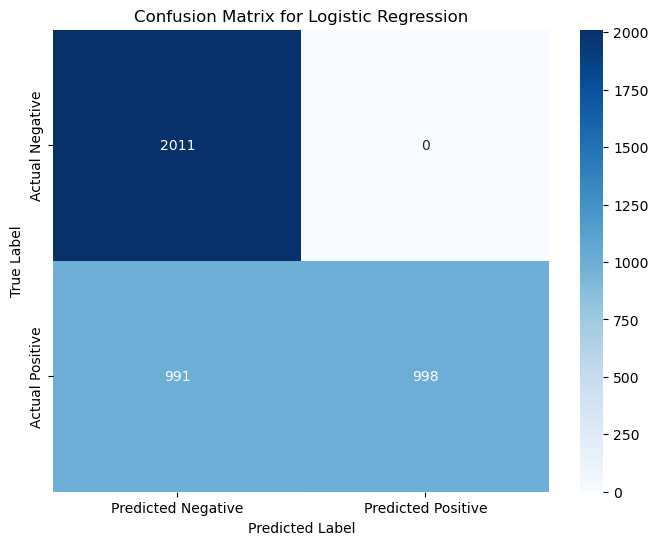

In [89]:
model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets and binary classification
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


In [90]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7522
Precision: 1.0000
Recall: 0.5018
F1-Score: 0.6682
ROC AUC: 0.7604


Train and Evaluate Other Classification Models

In [91]:
model_performance = {}
print("Initialized a dictionary to store model performance metrics.")

Initialized a dictionary to store model performance metrics.


--- RandomForestClassifier Metrics ---
Accuracy: 0.7435
Precision: 0.9454
Recall: 0.5138
F1-Score: 0.6658
ROC AUC: 0.7506


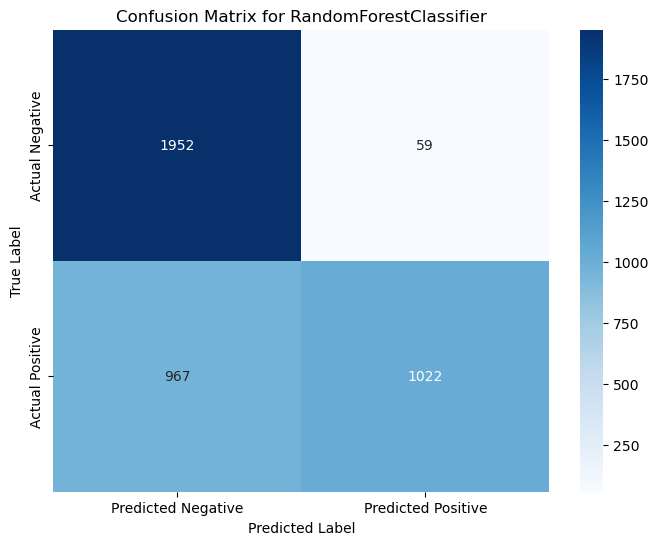

In [92]:
model_name = 'RandomForestClassifier'
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

model_performance[model_name] = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'ROC AUC': roc_auc_rf
}

print(f"--- {model_name} Metrics ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC: {roc_auc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

In [93]:
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10)

has_diabetic_retinopathy    0.318663
cholesterol_percentage      0.078570
glucose_percentage          0.078042
health_risk_score           0.078010
sugar_percentage            0.077033
obesity_percentage          0.075520
age                         0.063351
heart_rate                  0.061278
systolic                    0.057919
diastolic                   0.055379
dtype: float64

--- GradientBoostingClassifier Metrics ---
Accuracy: 0.7515
Precision: 0.9960
Recall: 0.5023
F1-Score: 0.6678
ROC AUC: 0.7490


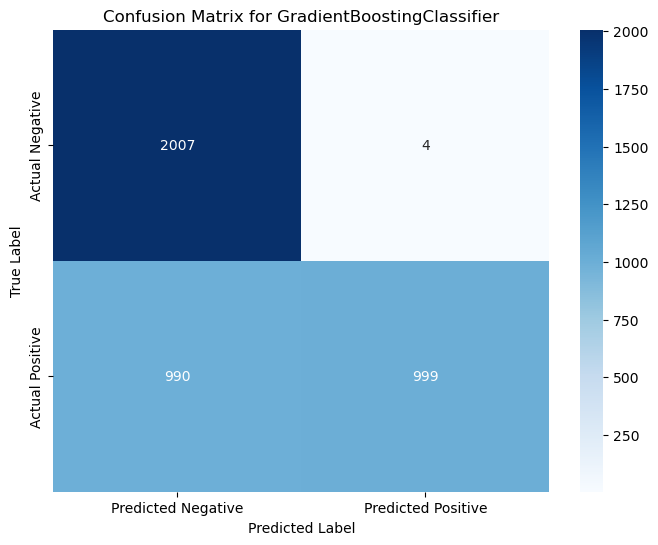

In [94]:
model_name = 'GradientBoostingClassifier'
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)

y_pred_gbc = gbc_model.predict(X_test)
y_proba_gbc = gbc_model.predict_proba(X_test)[:, 1]

accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
precision_gbc = precision_score(y_test, y_pred_gbc)
recall_gbc = recall_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_auc_gbc = roc_auc_score(y_test, y_proba_gbc)

model_performance[model_name] = {
    'Accuracy': accuracy_gbc,
    'Precision': precision_gbc,
    'Recall': recall_gbc,
    'F1-Score': f1_gbc,
    'ROC AUC': roc_auc_gbc
}

print(f"--- {model_name} Metrics ---")
print(f"Accuracy: {accuracy_gbc:.4f}")
print(f"Precision: {precision_gbc:.4f}")
print(f"Recall: {recall_gbc:.4f}")
print(f"F1-Score: {f1_gbc:.4f}")
print(f"ROC AUC: {roc_auc_gbc:.4f}")

cm_gbc = confusion_matrix(y_test, y_pred_gbc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

--- SVC Metrics ---
Accuracy: 0.7522
Precision: 1.0000
Recall: 0.5018
F1-Score: 0.6682
ROC AUC: 0.7404


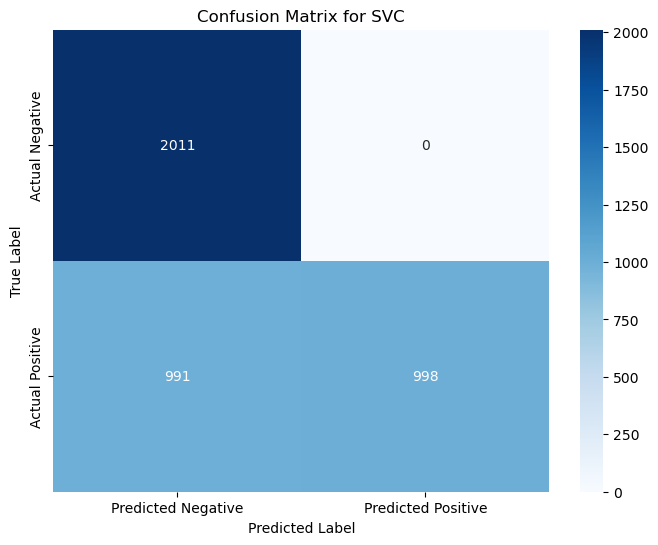

In [101]:
model_name = 'SVC'
svc_model = SVC(random_state=42, probability=True)
svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)
y_proba_svc = svc_model.predict_proba(X_test)[:, 1]

accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)
roc_auc_svc = roc_auc_score(y_test, y_proba_svc)

model_performance[model_name] = {
    'Accuracy': accuracy_svc,
    'Precision': precision_svc,
    'Recall': recall_svc,
    'F1-Score': f1_svc,
    'ROC AUC': roc_auc_svc
}

print(f"--- {model_name} Metrics ---")
print(f"Accuracy: {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall: {recall_svc:.4f}")
print(f"F1-Score: {f1_svc:.4f}")
print(f"ROC AUC: {roc_auc_svc:.4f}")

cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

In [96]:
model_comparison_df = pd.DataFrame.from_dict(model_performance, orient='index')
print(model_comparison_df)

                            Accuracy  Precision    Recall  F1-Score   ROC AUC
RandomForestClassifier       0.74350   0.945421  0.513826  0.665798  0.750597
GradientBoostingClassifier   0.75150   0.996012  0.502262  0.667781  0.748961
SVC                          0.75225   1.000000  0.501760  0.668229  0.740371


Voting Classifier

In [97]:
from sklearn.ensemble import VotingClassifier

estimators = [
    ('lr', model), # Logistic Regression
    ('rf', rf_model), # RandomForestClassifier
    ('gbc', gbc_model), # GradientBoostingClassifier
    ('svc', svc_model) # SVC
]

voting_clf = VotingClassifier(estimators=estimators, voting='soft', weights=[1, 1, 1, 1], flatten_transform=True)
voting_clf.fit(X_train, y_train)
y_pred_vt = voting_clf.predict(X_test)
y_proba_vt = voting_clf.predict_proba(X_test)[:, 1]
print("VotingClassifier trained and predictions made.")

VotingClassifier trained and predictions made.


Voting Classifier trained and predictions made

--- VotingClassifier Metrics ---
Accuracy: 0.7522
Precision: 0.9990
Recall: 0.5023
F1-Score: 0.6685
ROC AUC: 0.7495


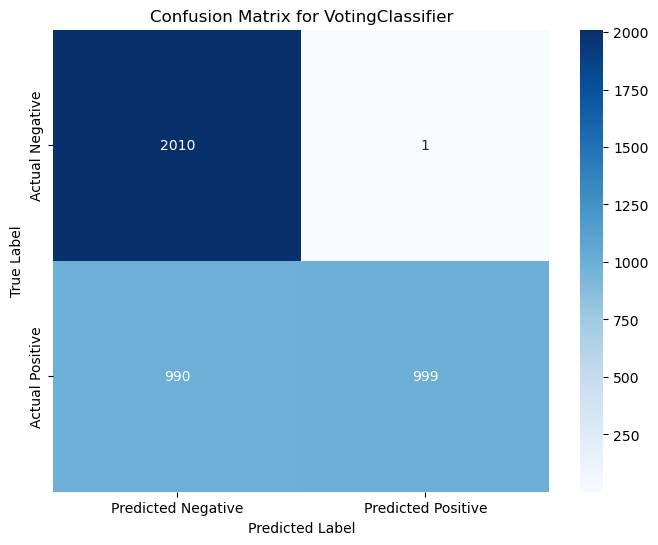

In [98]:
accuracy_vt = accuracy_score(y_test, y_pred_vt)
precision_vt = precision_score(y_test, y_pred_vt)
recall_vt = recall_score(y_test, y_pred_vt)
f1_vt = f1_score(y_test, y_pred_vt)
roc_auc_vt = roc_auc_score(y_test, y_proba_vt)

model_performance['VotingClassifier'] = {
    'Accuracy': accuracy_vt,
    'Precision': precision_vt,
    'Recall': recall_vt,
    'F1-Score': f1_vt,
    'ROC AUC': roc_auc_vt
}

print("--- VotingClassifier Metrics ---")
print(f"Accuracy: {accuracy_vt:.4f}")
print(f"Precision: {precision_vt:.4f}")
print(f"Recall: {recall_vt:.4f}")
print(f"F1-Score: {f1_vt:.4f}")
print(f"ROC AUC: {roc_auc_vt:.4f}")

cm_vt = confusion_matrix(y_test, y_pred_vt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for VotingClassifier')
plt.show()

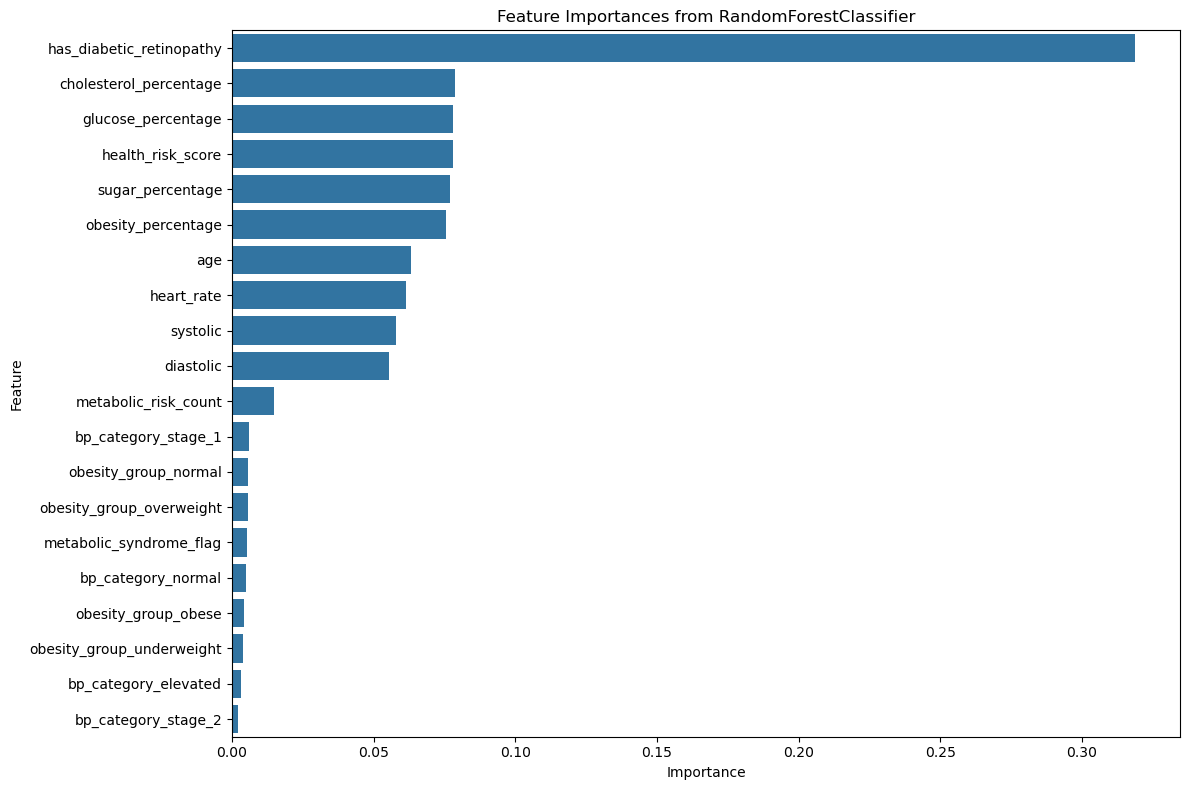

,Feature,Importance
1,has_diabetic_retinopathy,0.318663
4,cholesterol_percentage,0.078570
3,glucose_percentage,0.078042
11,health_risk_score,0.078010
2,sugar_percentage,0.077033
5,obesity_percentage,0.075520
0,age,0.063351
6,heart_rate,0.061278
7,systolic,0.057919
8,diastolic,0.055379


In [99]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(importance_df)

XGBoost


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.8}

--- Threshold Comparison ---
Threshold: 0.30 | Precision: 0.5297 | Recall: 0.8738 | F1: 0.6596
Threshold: 0.32 | Precision: 0.5601 | Recall: 0.8014 | F1: 0.6594
Threshold: 0.35 | Precision: 0.6392 | Recall: 0.6858 | F1: 0.6617

✅ Selected Best Threshold: 0.30

--- Final XGBClassifier Metrics ---
Accuracy: 0.5515
Precision: 0.5297
Recall: 0.8738
F1-Score: 0.6596
ROC AUC: 0.7421


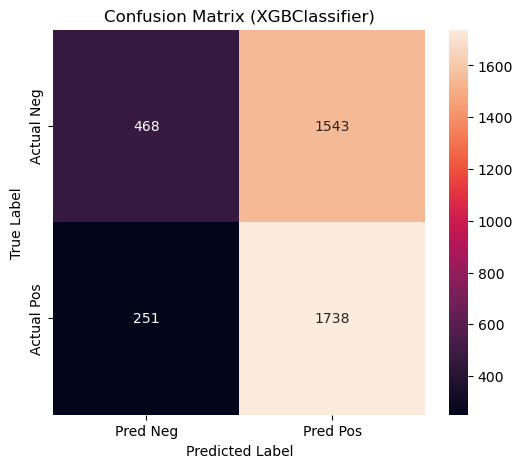

In [100]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_name = 'XGBClassifier'

# ✅ Handle class imbalance
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

# ✅ Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1]
}

# ✅ GridSearch (optimize F1)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best model
best_xgb_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Train model
best_xgb_model.fit(X_train, y_train)

# Predict probabilities
y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# 🎯 Try multiple thresholds
thresholds_to_try = [0.30, 0.32, 0.35]

best_f1 = 0
best_threshold = 0.5
best_metrics = {}

print("\n--- Threshold Comparison ---")

for t in thresholds_to_try:
    y_pred_temp = (y_proba_xgb > t).astype(int)
    
    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)
    
    print(f"Threshold: {t:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    
    # ✅ Select best threshold based on F1 (with good recall)
    if f1 > best_f1 and recall >= 0.80:
        best_f1 = f1
        best_threshold = t
        best_metrics = (precision, recall, f1)

print(f"\n✅ Selected Best Threshold: {best_threshold:.2f}")

# Apply best threshold
y_pred_xgb = (y_proba_xgb > best_threshold).astype(int)

# ✅ Final Evaluation
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"\n--- Final {model_name} Metrics ---")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")

# ✅ Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d',
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix ({model_name})')
plt.show()